### Calculating and plotting the Wigner-Ville spectrum of and LSP

The Wigner–Ville spectrum (WVS) is the stochastic version of the classical Wigner–Ville
distribution in (3) [29], defined as:

$
W(t, \omega) = \int_{-\infty}^{\infty} 
\mathbb{E}\left[ X\left(t + \tfrac{\tau}{2}\right) X^{*}\left(t - \tfrac{\tau}{2}\right) \right] 
e^{-i \tau \omega} \, d\tau.
$

The traditional estimate of the WVS based on one realization of the process is equivalent
to estimating the Wigner–Ville distribution (WV) (3). For LSPs, the WVS assumes the
advantageous expression:

$
W(t, \omega) = q(t) \cdot F_r(\omega)
$


Peak ~ f = 65.0 Hz,  t = 0.19921875 s


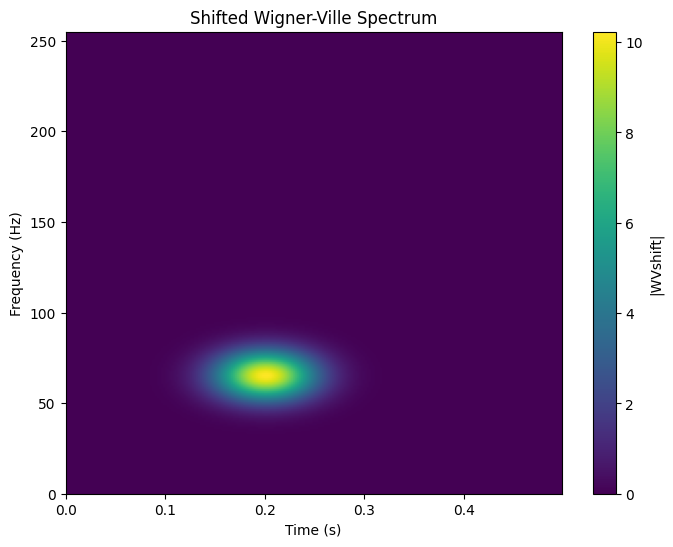

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from lsp_sim.wv_lsp import wvshifted_lsp

# Parameters
a_q = 500
b_q = 0.2
c_q = 800
c_r = 15000
L = 0
dataN = 256

T0 = 0
Tf = 0.5
delta_t = abs(Tf - T0) / (dataN - 1)
time_vec = T0 + np.arange(dataN) * delta_t

fs = 512
f0 = 65   # Hz
nfft = 512

WVshift, TI, FI, WV0 = wvshifted_lsp(L, a_q, b_q, c_q, c_r, dataN, f0, fs, nfft)

# Check peak freq and time
# If WVshift is (time, freq): use WVshift.T in sums
peak_freq_bin = np.argmax(np.abs(WVshift).T.sum(axis=1))
peak_time_bin = np.argmax(np.abs(WVshift).sum(axis=1))
print("Peak ~ f =", FI[peak_freq_bin], "Hz,  t =", TI[peak_time_bin], "s")


# Quick visualization
plt.figure(figsize=(8,6))
plt.imshow(np.abs(WVshift).T, aspect='auto',
           extent=[TI[0], TI[-1], FI[0], FI[-1]],
           origin='lower')
plt.colorbar(label='|WVshift|')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Shifted Wigner-Ville Spectrum")

plt.show()